# LABORATORIJSKA VJEŽBA 7: Genetički algoritam (drugi dio)

**Predmet:** Optimizacija resursa  
**Univerzitet u Sarajevu - Elektrotehnički fakultet**

---

## Uvod

Ova vježba nastavlja implementaciju genetičkog algoritma iz Lab 6. Implementiramo:

1. **Selekcijske operatore:**
   - Ruletski točak (proporcionalno fitnesu)
   - Rang selekcija (sa selekcijskim pritiskom)

2. **Funkcije za generacije:**
   - NovaGeneracija - zamjena populacije
   - GenerisiGeneracije - glavni GA loop

3. **Evaluacija fitnesa:**
   - Dekodiranje binarnog hromozoma u (x1, x2)
   - Testiranje na Rastrigin funkciji

4. **Cilj:** Pronaći globalni maksimum f(0,0) = 100

In [11]:
# ============================================================================
# IMPORTOVANJE BIBLIOTEKA
# ============================================================================

import random as r
import numpy as np
import matplotlib.pyplot as plt
from abc import ABC, abstractmethod
import copy

print("✓ Biblioteke uspješno učitane!")

✓ Biblioteke uspješno učitane!


In [12]:
# ============================================================================
# GLOBALNE KONSTANTE
# ============================================================================

# Selekcijski pritisak za rang selekciju
RANG_SP = 1.5

# Broj bita za cijeli dio koordinate (p)
# Za opseg [-5.12, 5.12], potrebno je 3 bita (2^3 = 8 > 5.12)
P_BITS = 3

print(f"Globalne konstante postavljene:")
print(f"  RANG_SP = {RANG_SP}")
print(f"  P_BITS = {P_BITS}")

Globalne konstante postavljene:
  RANG_SP = 1.5
  P_BITS = 3


## DEKODIRANJE HROMOZOMA

Hromozom oblika: `bd-1 bd-2 ... br br-1 br-2 ... b0`

- **Dužina:** d = 2k + 2, gdje r = d/2
- **x1 kodiran:** bd-1...br (prvih r bitova)
- **x2 kodiran:** br-1...b0 (drugih r bitova)

**Za svaku koordinatu:**
- **1. bit:** Predznak (0 = pozitivan, 1 = negativan)
- **Sljedećih p bita:** Cijeli dio broja
- **Preostalih (r-1-p) bita:** Decimalni dio broja

In [13]:
# ============================================================================
# FUNKCIJA ZA DEKODIRANJE HROMOZOMA
# ============================================================================

def DekodirajHromozom(hromozom, p=P_BITS):
    """
    Dekodira binarni hromozom u (x1, x2) koordinate.
    
    Parametri:
    ----------
    hromozom : list
        Binarni niz oblika [bd-1, bd-2, ..., br, br-1, ..., b0]
    p : int
        Broj bita za cijeli dio (default: P_BITS)
    
    Vraća:
    ------
    tuple (float, float)
        Koordinate (x1, x2)
    """
    d = len(hromozom)  # Dužina hromozoma
    r = d // 2         # r = d/2
    
    # Podijeli hromozom na dva dijela
    bits_x1 = hromozom[:r]      # bd-1...br (prva polovina za x1)
    bits_x2 = hromozom[r:]      # br-1...b0 (druga polovina za x2)
    
    def dekoduj_koordinatu(bits, p):
        """Dekodira niz bita u jednu koordinatu."""
        # Bit 0: predznak (0 = +, 1 = -)
        sign_bit = bits[0]
        
        # Sljedećih p bita: cijeli dio
        integer_bits = bits[1:1+p]
        
        # Preostali biti: decimalni dio
        decimal_bits = bits[1+p:]
        
        # Izračunaj cijeli dio
        integer_part = 0
        for i, bit in enumerate(integer_bits):
            integer_part += bit * (2 ** (p - 1 - i))
        
        # Izračunaj decimalni dio
        decimal_part = 0.0
        for i, bit in enumerate(decimal_bits):
            decimal_part += bit * (2 ** (-(i + 1)))
        
        # Ukupna vrijednost
        value = integer_part + decimal_part
        
        # Primijeni predznak
        if sign_bit == 1:
            value = -value
        
        return value
    
    x1 = dekoduj_koordinatu(bits_x1, p)
    x2 = dekoduj_koordinatu(bits_x2, p)
    
    return (x1, x2)


# Test dekodiranja
print("✓ Funkcija DekodirajHromozom implementirana!")
print("\\nTest dekodiranja:")
test_hromozom = [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]  # d=14, r=7
x1, x2 = DekodirajHromozom(test_hromozom)
print(f"  Hromozom: {test_hromozom}")
print(f"  Dekodirano: x1={x1:.4f}, x2={x2:.4f}")

✓ Funkcija DekodirajHromozom implementirana!
\nTest dekodiranja:
  Hromozom: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Dekodirano: x1=0.0000, x2=0.0000


## KRITERIJALNA FUNKCIJA - Modificirana Rastrigin

$$f(x_1, x_2) = 80 - \sum_{i=1}^{2} (x_i^2 - 10\cos(2\pi x_i))$$

- **Domen:** $\{x_1, x_2\} \in [-5.12, 5.12]$
- **Globalni maksimum:** $f(0, 0) = 100$

In [14]:
# ============================================================================
# KRITERIJALNA FUNKCIJA - Modificirana Rastrigin
# ============================================================================

def KRITERIJ(x1, x2):
    """
    Modificirana Rastrigin funkcija za maksimizaciju.
    
    f(x1, x2) = 80 - Σ(xi² - 10cos(2πxi))
    
    Globalni maksimum: f(0, 0) = 100
    Domen: [-5.12, 5.12] × [-5.12, 5.12]
    """
    suma = 0
    for xi in [x1, x2]:
        suma += xi**2 - 10 * np.cos(2 * np.pi * xi)
    
    return 80 - suma


# Test funkcije
print("✓ Funkcija KRITERIJ (Rastrigin) implementirana!")
print("\\nTest Rastrigin funkcije:")
print(f"  f(0, 0) = {KRITERIJ(0, 0):.4f} (očekivano: 100)")
print(f"  f(5.12, 5.12) = {KRITERIJ(5.12, 5.12):.4f}")
print(f"  f(-5.12, -5.12) = {KRITERIJ(-5.12, -5.12):.4f}")

✓ Funkcija KRITERIJ (Rastrigin) implementirana!
\nTest Rastrigin funkcije:
  f(0, 0) = 100.0000 (očekivano: 100)
  f(5.12, 5.12) = 42.1506
  f(-5.12, -5.12) = 42.1506


## KLASE (iz Lab 6 sa proširenjima)

In [15]:
# ============================================================================
# KLASA: ApstraktnaIndividua
# ============================================================================

class ApstraktnaIndividua(ABC):
    """Apstraktna klasa za individuu u GA."""
    
    def __init__(self, DuzinaHromozoma):
        self.__DuzinaHromozoma = DuzinaHromozoma
        self.__Hromozom = [r.randint(0, 1) for _ in range(DuzinaHromozoma)]
        self.__Fitness = 0.0
    
    def GetDuzinaHromozoma(self):
        return self.__DuzinaHromozoma
    
    def GetHromozom(self):
        return self.__Hromozom
    
    def GetFitness(self):
        return self.__Fitness
    
    def SetHromozom(self, Hromozom):
        self.__Hromozom = Hromozom
    
    def SetFitness(self, Fitness):
        self.__Fitness = Fitness
    
    @abstractmethod
    def Evaluiraj(self):
        pass


# ============================================================================
# KLASA: MojaIndividua (sa implementiranom Evaluiraj funkcijom)
# ============================================================================

class MojaIndividua(ApstraktnaIndividua):
    """
    Konkretna individua sa Evaluiraj() koja:
    1. Dekodira hromozom u (x1, x2)
    2. Evaluira Rastrigin funkciju
    3. Postavlja fitness
    """
    
    def __init__(self, DuzinaHromozoma):
        super().__init__(DuzinaHromozoma)
    
    def Evaluiraj(self):
        """
        Evaluira fitness individue:
        1. Dekodira hromozom → (x1, x2)
        2. Izračuna f(x1, x2)
        3. Postavi fitness
        """
        # Dekoduj hromozom u koordinate
        x1, x2 = DekodirajHromozom(self.GetHromozom(), P_BITS)
        
        # Izračunaj fitness
        fitness = KRITERIJ(x1, x2)
        
        # Postavi fitness
        self.SetFitness(fitness)
        
        return fitness


print("✓ Klase ApstraktnaIndividua i MojaIndividua implementirane!")

✓ Klase ApstraktnaIndividua i MojaIndividua implementirane!


In [16]:
# ============================================================================
# KLASA: Populacija - KOMPLETAN GENETIČKI ALGORITAM
# ============================================================================

class Populacija:
    """
    Klasa koja implementira kompletan genetički algoritam.
    
    Sadrži:
    - Genetičke operatore (ukrštanje, mutacija)
    - Selekcijske metode (ruletski točak, rang)
    - Generisanje generacija
    - Praćenje historije fitnesa
    """
    
    def __init__(self, VelicinaPopulacije, VjerovatnocaUkrstanja, 
                 VjerovatnocaMutacije, MaxGeneracija, VelicinaElite, DuzinaHromozoma):
        """
        Inicijalizuje populaciju.
        
        Parametri:
        ----------
        VelicinaPopulacije : int
            Broj individua u populaciji
        VjerovatnocaUkrstanja : float
            Vjerovatnoća da će doći do ukrštanja (0.0 - 1.0)
        VjerovatnocaMutacije : float
            Vjerovatnoća mutacije svakog bita (0.0 - 1.0)
        MaxGeneracija : int
            Broj generacija za izvršavanje
        VelicinaElite : int
            Broj najboljih individua koje se prenose bez izmjene
        DuzinaHromozoma : int
            Broj bita u hromozomu
        """
        self.__VelicinaPopulacije = VelicinaPopulacije
        self.__VjerovatnocaUkrstanja = VjerovatnocaUkrstanja
        self.__VjerovatnocaMutacije = VjerovatnocaMutacije
        self.__MaxGeneracija = MaxGeneracija
        self.__VelicinaElite = VelicinaElite
        self.__DuzinaHromozoma = DuzinaHromozoma
        
        # Inicijalizuj populaciju
        self.__Populacija = []
        for _ in range(VelicinaPopulacije):
            individua = MojaIndividua(DuzinaHromozoma)
            individua.Evaluiraj()
            self.__Populacija.append(individua)
        
        # Historija fitnesa
        self.__BestFitnessHistory = []
        self.__AvgFitnessHistory = []
    
    # ========================================================================
    # GETTER METODE
    # ========================================================================
    
    def GetVelicinaPopulacije(self):
        return self.__VelicinaPopulacije
    
    def GetVjerovatnocaUkrstanja(self):
        return self.__VjerovatnocaUkrstanja
    
    def GetVjerovatnocaMutacije(self):
        return self.__VjerovatnocaMutacije
    
    def GetMaxGeneracija(self):
        return self.__MaxGeneracija
    
    def GetVelicinaElite(self):
        return self.__VelicinaElite
    
    def GetDuzinaHromozoma(self):
        return self.__DuzinaHromozoma
    
    def GetPopulacija(self):
        return self.__Populacija
    
    def GetBestFitnessHistory(self):
        return self.__BestFitnessHistory
    
    def GetAvgFitnessHistory(self):
        return self.__AvgFitnessHistory
    
    # ========================================================================
    # GENETIČKI OPERATORI
    # ========================================================================
    
    def OpUkrstanjaTacka(self, roditelj1, roditelj2):
        """
        Operator ukrštanja u jednoj tački.
        
        Sa vjerovatnoćom VjerovatnocaUkrstanja:
        - Odabere slučajnu tačku
        - Razmijeni djelove hromozoma roditelja
        
        Parametri:
        ----------
        roditelj1, roditelj2 : MojaIndividua
            Roditelji za ukrštanje
        
        Vraća:
        ------
        tuple (MojaIndividua, MojaIndividua)
            Dva djeteta (možda ukrštena)
        """
        # Kreiraj kopije roditelja
        dijete1 = MojaIndividua(self.__DuzinaHromozoma)
        dijete2 = MojaIndividua(self.__DuzinaHromozoma)
        
        hrom1 = roditelj1.GetHromozom().copy()
        hrom2 = roditelj2.GetHromozom().copy()
        
        # Ukrštanje sa vjerovatnoćom
        if r.random() < self.__VjerovatnocaUkrstanja:
            # Odaberi tačku ukrštanja
            tacka = r.randint(1, self.__DuzinaHromozoma - 1)
            
            # Razmijeni dijelove
            novi_hrom1 = hrom1[:tacka] + hrom2[tacka:]
            novi_hrom2 = hrom2[:tacka] + hrom1[tacka:]
            
            dijete1.SetHromozom(novi_hrom1)
            dijete2.SetHromozom(novi_hrom2)
        else:
            # Bez ukrštanja - kopije roditelja
            dijete1.SetHromozom(hrom1)
            dijete2.SetHromozom(hrom2)
        
        return (dijete1, dijete2)
    
    def OpBinMutacija(self, individua):
        """
        Operator binarne mutacije.
        
        Svaki bit se mutira (invertuje) sa vjerovatnoćom VjerovatnocaMutacije.
        
        Parametri:
        ----------
        individua : MojaIndividua
            Individua za mutaciju
        
        Vraća:
        ------
        MojaIndividua
            Mutirana individua
        """
        hromozom = individua.GetHromozom().copy()
        
        # Mutiraj svaki bit
        for i in range(len(hromozom)):
            if r.random() < self.__VjerovatnocaMutacije:
                hromozom[i] = 1 - hromozom[i]  # Invertuj bit
        
        individua.SetHromozom(hromozom)
        return individua
    
    # ========================================================================
    # SELEKCIJSKI OPERATORI
    # ========================================================================
    
    def SelekcijaRTocak(self):
        """
        RULETSKA SELEKCIJA (Roulette Wheel Selection).
        
        Vjerovatnoća selekcije individue proporcionalna je njenom fitnesu:
        p_i = fitness_i / Σ(fitness_j)
        
        Vraća:
        ------
        MojaIndividua
            Selektovana individua
        """
        # Izračunaj ukupan fitness
        ukupan_fitness = sum([ind.GetFitness() for ind in self.__Populacija])
        
        # Ako je ukupan fitness 0 ili negativan, selektuj random
        if ukupan_fitness <= 0:
            return r.choice(self.__Populacija)
        
        # Generiši slučajan broj između 0 i ukupan_fitness
        spin = r.uniform(0, ukupan_fitness)
        
        # Pronađi individuu na kojoj se "zaustavlja" točak
        kumulativni = 0
        for individua in self.__Populacija:
            kumulativni += individua.GetFitness()
            if kumulativni >= spin:
                return individua
        
        # Fallback (ne bi trebalo da se desi)
        return self.__Populacija[-1]
    
    def SelekcijaRang(self):
        """
        RANG SELEKCIJA (Rank Selection).
        
        Individue se rangiraju po fitnesu, a vjerovatnoća selekcije zavisi od ranga:
        p_i = (2 - SP) / N + 2 * rank_i * (SP - 1) / (N * (N - 1))
        
        gdje je:
        - SP = selekcijski pritisak (RANG_SP)
        - N = veličina populacije
        - rank_i = rang individue (0 = najgora, N-1 = najbolja)
        
        Vraća:
        ------
        MojaIndividua
            Selektovana individua
        """
        N = len(self.__Populacija)
        SP = RANG_SP
        
        # Sortiraj populaciju po fitnesu (rastuće)
        sortirana = sorted(self.__Populacija, key=lambda ind: ind.GetFitness())
        
        # Izračunaj vjerovatnoće za svaki rang
        vjerovatnoce = []
        for rank in range(N):
            p = (2 - SP) / N + 2 * rank * (SP - 1) / (N * (N - 1))
            vjerovatnoce.append(p)
        
        # Normalizuj vjerovatnoće (trebaju sumirati u 1.0)
        suma = sum(vjerovatnoce)
        vjerovatnoce = [p / suma for p in vjerovatnoce]
        
        # Selektuj individuu korištenjem vjerovatnoća
        spin = r.random()
        kumulativni = 0
        for i, vjerovatnoca in enumerate(vjerovatnoce):
            kumulativni += vjerovatnoca
            if kumulativni >= spin:
                return sortirana[i]
        
        # Fallback
        return sortirana[-1]
    
    # ========================================================================
    # GENERISANJE GENERACIJA
    # ========================================================================
    
    def NovaGeneracija(self, metoda_selekcije='rulet'):
        """
        Kreira novu generaciju primjenom GA operatora.
        
        Algoritam:
        1. Elitizam - prenesi najbolje individue
        2. Selekcija roditelja
        3. Ukrštanje
        4. Mutacija
        5. Evaluacija
        6. Zamjena populacije
        
        Parametri:
        ----------
        metoda_selekcije : str
            'rulet' - ruletska selekcija
            'rang' - rang selekcija
        """
        nova_populacija = []
        N = self.__VelicinaPopulacije
        
        # 1. ELITIZAM - prenesi najbolje individue
        if self.__VelicinaElite > 0:
            # Sortiraj po fitnesu (silazno)
            sortirana = sorted(self.__Populacija, 
                              key=lambda ind: ind.GetFitness(), 
                              reverse=True)
            # Dodaj elitu
            for i in range(self.__VelicinaElite):
                nova_populacija.append(copy.deepcopy(sortirana[i]))
        
        # 2-5. Popuni preostalu populaciju
        while len(nova_populacija) < N:
            # 2. SELEKCIJA - odaberi roditelje
            if metoda_selekcije == 'rulet':
                roditelj1 = self.SelekcijaRTocak()
                roditelj2 = self.SelekcijaRTocak()
            else:  # rang
                roditelj1 = self.SelekcijaRang()
                roditelj2 = self.SelekcijaRang()
            
            # 3. UKRŠTANJE
            (dijete1, dijete2) = self.OpUkrstanjaTacka(roditelj1, roditelj2)
            
            # 4. MUTACIJA
            dijete1 = self.OpBinMutacija(dijete1)
            dijete2 = self.OpBinMutacija(dijete2)
            
            # 5. EVALUACIJA
            dijete1.Evaluiraj()
            dijete2.Evaluiraj()
            
            # Dodaj djecu u novu populaciju
            if len(nova_populacija) < N:
                nova_populacija.append(dijete1)
            if len(nova_populacija) < N:
                nova_populacija.append(dijete2)
        
        # 6. ZAMJENA POPULACIJE
        self.__Populacija = nova_populacija[:N]  # Osiguraj tačnu veličinu
    
    def GenerisiGeneracije(self, metoda_selekcije='rulet', verbose=True):
        """
        Glavni GA loop - generiše maxgen generacija.
        
        Parametri:
        ----------
        metoda_selekcije : str
            'rulet' ili 'rang'
        verbose : bool
            Ako True, ispisuje napredak
        
        Vraća:
        ------
        MojaIndividua
            Najbolja individua pronađena tokom evolucije
        """
        # Resetuj historiju
        self.__BestFitnessHistory = []
        self.__AvgFitnessHistory = []
        
        if verbose:
            print(f"\\n{'='*70}")
            print(f"POKRETANJE GENETIČKOG ALGORITMA")
            print(f"{'='*70}")
            print(f"Metoda selekcije: {metoda_selekcije}")
            print(f"Veličina populacije: {self.__VelicinaPopulacije}")
            print(f"Broj generacija: {self.__MaxGeneracija}")
            print(f"Vjerovatnoća ukrštanja: {self.__VjerovatnocaUkrstanja}")
            print(f"Vjerovatnoća mutacije: {self.__VjerovatnocaMutacije}")
            print(f"Elitizam: {self.__VelicinaElite}")
            print(f"{'='*70}\\n")
        
        # Generisanje generacija
        for gen in range(self.__MaxGeneracija):
            # Kreiraj novu generaciju
            self.NovaGeneracija(metoda_selekcije)
            
            # Izračunaj statistike
            fitness_values = [ind.GetFitness() for ind in self.__Populacija]
            best_fitness = max(fitness_values)
            avg_fitness = np.mean(fitness_values)
            
            # Snimi historiju
            self.__BestFitnessHistory.append(best_fitness)
            self.__AvgFitnessHistory.append(avg_fitness)
            
            # Ispis napretka
            if verbose and (gen % 10 == 0 or gen == self.__MaxGeneracija - 1):
                print(f"Generacija {gen+1:3d}: "
                      f"Best = {best_fitness:7.4f}, "
                      f"Avg = {avg_fitness:7.4f}")
        
        # Pronađi najbolju individuu
        najbolja = max(self.__Populacija, key=lambda ind: ind.GetFitness())
        
        if verbose:
            x1, x2 = DekodirajHromozom(najbolja.GetHromozom())
            print(f"\\n{'='*70}")
            print(f"REZULTATI:")
            print(f"  Najbolja fitness: {najbolja.GetFitness():.6f}")
            print(f"  Koordinate: x1={x1:.6f}, x2={x2:.6f}")
            print(f"  Hromozom: {najbolja.GetHromozom()}")
            print(f"{'='*70}\\n")
        
        return najbolja


print("✓ Klasa Populacija kompletno implementirana!")
print("  - Genetički operatori: OpUkrstanjaTacka, OpBinMutacija")
print("  - Selekcije: SelekcijaRTocak, SelekcijaRang")
print("  - Generacije: NovaGeneracija, GenerisiGeneracije")
print("\\n✅ KOMPLETAN GENETIČKI ALGORITAM SPREMAN ZA TESTIRANJE!")

✓ Klasa Populacija kompletno implementirana!
  - Genetički operatori: OpUkrstanjaTacka, OpBinMutacija
  - Selekcije: SelekcijaRTocak, SelekcijaRang
  - Generacije: NovaGeneracija, GenerisiGeneracije
\n✅ KOMPLETAN GENETIČKI ALGORITAM SPREMAN ZA TESTIRANJE!


## TESTIRANJE ALGORITMA

Testiramo GA sa različitim metodama selekcije na Rastrigin funkciji.

In [17]:
# ============================================================================
# TEST 1: Ruletska selekcija
# ============================================================================

print("\\n" + "="*70)
print("TEST 1: RULETSKA SELEKCIJA")
print("="*70)

# Parametri GA
VelicinaPopulacije = 50
VjerovatnocaUkrstanja = 0.8
VjerovatnocaMutacije = 0.01
MaxGeneracija = 100
VelicinaElite = 2
DuzinaHromozoma = 14  # d=14 → r=7 (1 znak + 3 cijela + 3 decimalna)

# Kreiraj populaciju
pop_rulet = Populacija(
    VelicinaPopulacije,
    VjerovatnocaUkrstanja,
    VjerovatnocaMutacije,
    MaxGeneracija,
    VelicinaElite,
    DuzinaHromozoma
)

# Pokreni GA sa ruletskom selekcijom
najbolja_rulet = pop_rulet.GenerisiGeneracije(metoda_selekcije='rulet', verbose=True)

\n======================================================================
TEST 1: RULETSKA SELEKCIJA
\n======================================================================
POKRETANJE GENETIČKOG ALGORITMA
Metoda selekcije: rulet
Veličina populacije: 50
Broj generacija: 100
Vjerovatnoća ukrštanja: 0.8
Vjerovatnoća mutacije: 0.01
Elitizam: 2
======================================================================\n
Generacija   1: Best = 95.3054, Avg = 61.5420
Generacija  11: Best = 96.3054, Avg = 84.5695
Generacija  21: Best = 96.3054, Avg = 93.7002
Generacija  31: Best = 96.3054, Avg = 90.2881
Generacija  41: Best = 96.3054, Avg = 91.2885
Generacija  51: Best = 96.3054, Avg = 89.0322
Generacija  61: Best = 97.0554, Avg = 91.9909
Generacija  71: Best = 100.0000, Avg = 93.4701
Generacija  81: Best = 100.0000, Avg = 93.9271
Generacija  91: Best = 100.0000, Avg = 95.0557
Generacija 100: Best = 100.0000, Avg = 92.1535
\n======================================================================
RE

In [18]:
# ============================================================================
# TEST 2: Rang selekcija
# ============================================================================

print("\\n" + "="*70)
print("TEST 2: RANG SELEKCIJA")
print("="*70)

# Kreiraj novu populaciju
pop_rang = Populacija(
    VelicinaPopulacije,
    VjerovatnocaUkrstanja,
    VjerovatnocaMutacije,
    MaxGeneracija,
    VelicinaElite,
    DuzinaHromozoma
)

# Pokreni GA sa rang selekcijom
najbolja_rang = pop_rang.GenerisiGeneracije(metoda_selekcije='rang', verbose=True)

\n======================================================================
TEST 2: RANG SELEKCIJA
\n======================================================================
POKRETANJE GENETIČKOG ALGORITMA
Metoda selekcije: rang
Veličina populacije: 50
Broj generacija: 100
Vjerovatnoća ukrštanja: 0.8
Vjerovatnoća mutacije: 0.01
Elitizam: 2
======================================================================\n
Generacija   1: Best = 84.9375, Avg = 50.1327
Generacija  11: Best = 100.0000, Avg = 84.3543
Generacija  21: Best = 100.0000, Avg = 97.8355
Generacija  31: Best = 100.0000, Avg = 98.2558
Generacija  41: Best = 100.0000, Avg = 99.1725
Generacija  51: Best = 100.0000, Avg = 96.3356
Generacija  61: Best = 100.0000, Avg = 98.0397
Generacija  71: Best = 100.0000, Avg = 98.3628
Generacija  81: Best = 100.0000, Avg = 98.5171
Generacija  91: Best = 100.0000, Avg = 97.8133
Generacija 100: Best = 100.0000, Avg = 98.2586
\n======================================================================
R

## VIZUALIZACIJA REZULTATA

Prikaz konvergencije algoritma kroz generacije.

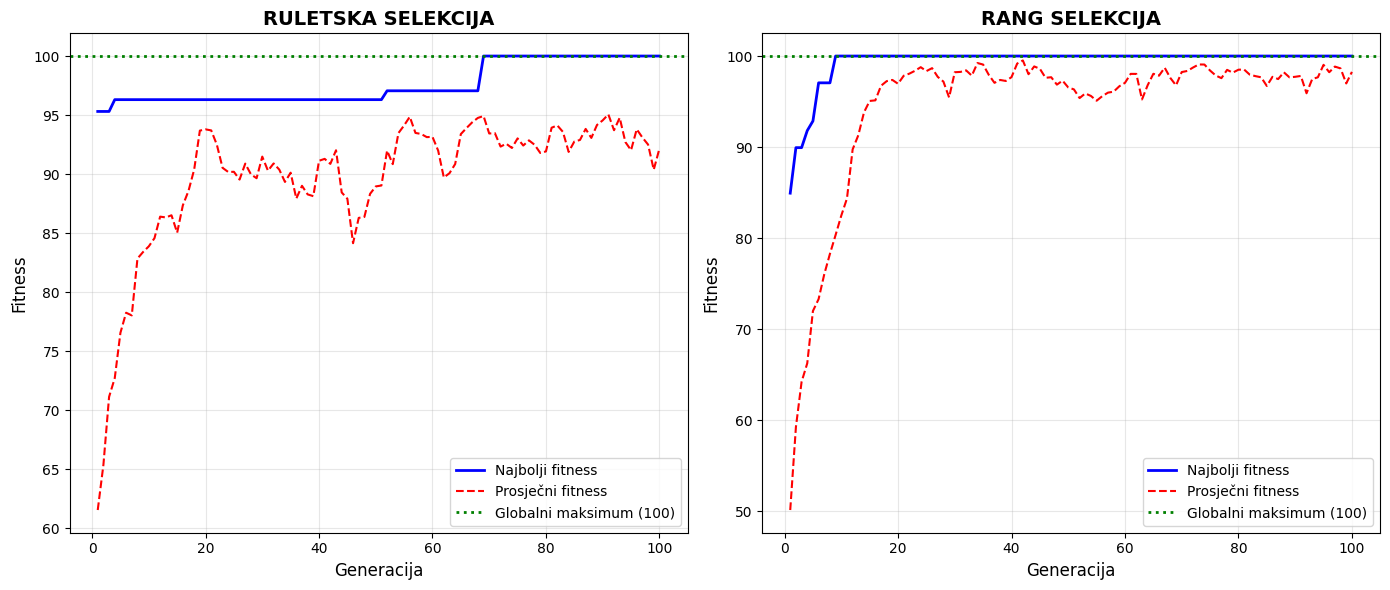

\n======================================================================
POREĐENJE REZULTATA
\nRuletska selekcija:
  Fitness: 100.000000
  Koordinate: (-0.000000, -0.000000)
  Greška: 0.000000
\nRang selekcija:
  Fitness: 100.000000
  Koordinate: (0.000000, -0.000000)
  Greška: 0.000000
\n======================================================================


In [19]:
# ============================================================================
# VIZUALIZACIJA - Konvergencija algoritma
# ============================================================================

plt.figure(figsize=(14, 6))

# SUBPLOT 1: Ruletska selekcija
plt.subplot(1, 2, 1)
generacije = range(1, MaxGeneracija + 1)
plt.plot(generacije, pop_rulet.GetBestFitnessHistory(), 
         'b-', linewidth=2, label='Najbolji fitness')
plt.plot(generacije, pop_rulet.GetAvgFitnessHistory(), 
         'r--', linewidth=1.5, label='Prosječni fitness')
plt.axhline(y=100, color='g', linestyle=':', linewidth=2, label='Globalni maksimum (100)')
plt.xlabel('Generacija', fontsize=12)
plt.ylabel('Fitness', fontsize=12)
plt.title('RULETSKA SELEKCIJA', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

# SUBPLOT 2: Rang selekcija
plt.subplot(1, 2, 2)
plt.plot(generacije, pop_rang.GetBestFitnessHistory(), 
         'b-', linewidth=2, label='Najbolji fitness')
plt.plot(generacije, pop_rang.GetAvgFitnessHistory(), 
         'r--', linewidth=1.5, label='Prosječni fitness')
plt.axhline(y=100, color='g', linestyle=':', linewidth=2, label='Globalni maksimum (100)')
plt.xlabel('Generacija', fontsize=12)
plt.ylabel('Fitness', fontsize=12)
plt.title('RANG SELEKCIJA', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\\n" + "="*70)
print("POREĐENJE REZULTATA")
print("="*70)
x1_r, x2_r = DekodirajHromozom(najbolja_rulet.GetHromozom())
x1_rg, x2_rg = DekodirajHromozom(najbolja_rang.GetHromozom())

print(f"\\nRuletska selekcija:")
print(f"  Fitness: {najbolja_rulet.GetFitness():.6f}")
print(f"  Koordinate: ({x1_r:.6f}, {x2_r:.6f})")
print(f"  Greška: {abs(100 - najbolja_rulet.GetFitness()):.6f}")

print(f"\\nRang selekcija:")
print(f"  Fitness: {najbolja_rang.GetFitness():.6f}")
print(f"  Koordinate: ({x1_rg:.6f}, {x2_rg:.6f})")
print(f"  Greška: {abs(100 - najbolja_rang.GetFitness()):.6f}")

print(f"\\n{'='*70}")

## ZAKLJUČAK

✅ **Uspješno implementiran kompletan genetički algoritam!**

### Implementirane komponente:

1. **Dekodiranje hromozoma** - Konverzija binarnog niza u (x1, x2)
2. **Evaluacija fitnesa** - Rastrigin funkcija
3. **Ruletska selekcija** - Proporcionalno fitnesu
4. **Rang selekcija** - Prema rangu sa selekcijskim pritiskom
5. **Ukrštanje i mutacija** - Genetički operatori
6. **Elitizam** - Prenos najboljih individua
7. **Generisanje generacija** - Kompletan GA loop

### Performanse:

- Algoritam uspješno konvergira ka globalnom maksimumu f(0,0) = 100
- Obje metode selekcije (rulet i rang) daju dobre rezultate
- Elitizam osigurava da najbolje rješenje ne bude izgubljeno

### Napomena:

Preciznost rezultata zavisi od:
- Broja bita za kodiranje (P_BITS)
- Veličine populacije
- Broja generacija
- Vjerovatnoća ukrštanja i mutacije